<a href="https://colab.research.google.com/github/wndjs319-wq/2025-LLM/blob/main/%EC%8A%A4%EB%A7%88%ED%8A%B8%EA%B5%90%EC%B0%A8%EB%A1%9C_%EA%B5%90%ED%86%B5%EB%9F%89%EB%B6%84%EC%84%9D_%EC%A7%80%EB%8F%84%ED%8F%AC%ED%95%A8_%EC%B5%9C%EC%A2%85%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 스마트교차로 일일 교통량 분석 + 교차로 위치 지도 시각화

이 노트북은 다음 두 CSV 파일을 이용합니다.

1. `VW_SC_TRF_VOL_DAILY.csv` : 스마트교차로 일일 교통량 데이터  
2. `서울시 노드 정보.csv` : 교차로 위치 좌표 데이터  

## 분석 내용
- 일자별 전체 교통량 변화
- 누적 교통량 상위 교차로 TOP 10
- 시간대별 전체 교통량
- 회전 유형별 누적 교통량
- 교차로별 누적 교통량 Folium 점 지도
- 지도 HTML 파일 및 연결 결과 CSV 다운로드

## 실행 순서
셀을 위에서 아래로 순서대로 실행하세요.  
첫 번째 파일 선택 창에는 `VW_SC_TRF_VOL_DAILY.csv`, 두 번째 파일 선택 창에는 `서울시 노드 정보.csv`를 업로드합니다.

In [1]:
# ============================================================
# 0. 라이브러리와 한글 폰트 설정
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from google.colab import files
from IPython.display import display

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", font="NanumGothic")

comma = FuncFormatter(lambda x, pos: f"{int(x):,}")
print("준비 완료")

준비 완료


In [2]:
# ============================================================
# 1. 스마트교차로 일일 교통량 CSV 업로드 및 불러오기
# ============================================================

print("VW_SC_TRF_VOL_DAILY.csv 파일을 선택하세요.")
uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
if not csv_files:
    raise ValueError("CSV 파일을 선택하지 않았습니다. VW_SC_TRF_VOL_DAILY.csv를 업로드하세요.")

csv_file_path = csv_files[0]

df = None
for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
    try:
        df = pd.read_csv(csv_file_path, encoding=enc)
        print(f"CSV 불러오기 완료: {csv_file_path} / 인코딩: {enc}")
        break
    except UnicodeDecodeError:
        continue

if df is None:
    raise ValueError("파일 인코딩을 확인할 수 없습니다.")

required = ["STND_DT", "CROSS_ID", "CROSS_NM", "TURN_TYPE_NM"]
missing = [col for col in required if col not in df.columns]
if missing:
    raise ValueError(
        f"이 노트북은 스마트교차로 일일 교통량 파일용입니다. 없는 컬럼: {missing}\n"
        f"현재 컬럼: {df.columns.tolist()}"
    )

print("데이터 크기:", df.shape)
print("컬럼 목록:", df.columns.tolist())
display(df.head())

VW_SC_TRF_VOL_DAILY.csv 파일을 선택하세요.


Saving VW_SC_TRF_VOL_DAILY.csv to VW_SC_TRF_VOL_DAILY.csv
CSV 불러오기 완료: VW_SC_TRF_VOL_DAILY.csv / 인코딩: utf-8-sig
데이터 크기: (2408, 33)
컬럼 목록: ['STND_DT', 'DAY_CD', 'DAY_NM', 'CROSS_ID', 'CROSS_NM', 'DIR_CD', 'DIR_NM', 'TURN_TYPE_CD', 'TURN_TYPE_NM', 'TURN_CNT0', 'TURN_CNT1', 'TURN_CNT2', 'TURN_CNT3', 'TURN_CNT4', 'TURN_CNT5', 'TURN_CNT6', 'TURN_CNT7', 'TURN_CNT8', 'TURN_CNT9', 'TURN_CNT10', 'TURN_CNT11', 'TURN_CNT12', 'TURN_CNT13', 'TURN_CNT14', 'TURN_CNT15', 'TURN_CNT16', 'TURN_CNT17', 'TURN_CNT18', 'TURN_CNT19', 'TURN_CNT20', 'TURN_CNT21', 'TURN_CNT22', 'TURN_CNT23']


,STND_DT,DAY_CD,DAY_NM,CROSS_ID,CROSS_NM,DIR_CD,DIR_NM,TURN_TYPE_CD,TURN_TYPE_NM,TURN_CNT0,...,TURN_CNT14,TURN_CNT15,TURN_CNT16,TURN_CNT17,TURN_CNT18,TURN_CNT19,TURN_CNT20,TURN_CNT21,TURN_CNT22,TURN_CNT23
0,20260426,1,일,172,태릉입구역,3,남,L,좌회전,190,...,398,360,403,404,399,383,302,252,286,217
1,20260426,1,일,1385,화랑대역,1,동,L,좌회전,71,...,0,0,0,0,0,0,0,0,0,0
2,20260427,2,월,1315,화랑대사거리,1,동,L,좌회전,22,...,125,126,159,167,155,120,91,87,47,23
3,20260427,2,월,172,태릉입구역,1,동,L,좌회전,109,...,250,286,275,335,274,189,99,94,138,107
4,20260427,2,월,1315,화랑대사거리,3,남,L,좌회전,278,...,485,483,509,535,597,608,542,486,317,284


In [3]:
# ============================================================
# 2. 전처리: 시간대 교통량 합계 만들기
# ============================================================

hour_cols = [f"TURN_CNT{i}" for i in range(24)]
missing_hours = [col for col in hour_cols if col not in df.columns]
if missing_hours:
    raise ValueError(f"시간대 교통량 컬럼이 없습니다: {missing_hours}")

analysis_df = df.copy()

# 날짜 변환
analysis_df["DATE"] = pd.to_datetime(
    analysis_df["STND_DT"].astype(str), format="%Y%m%d", errors="coerce"
)

# 시간대별 교통량 수치화
analysis_df[hour_cols] = analysis_df[hour_cols].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# 한 행의 하루 교통량: 0시~23시 합계
analysis_df["DAILY_TOTAL"] = analysis_df[hour_cols].sum(axis=1)

# 사용할 행만 정리
analysis_df = analysis_df.dropna(subset=["DATE", "CROSS_NM", "TURN_TYPE_NM"])

print("분석 대상 기간:", analysis_df["DATE"].min().date(), "~", analysis_df["DATE"].max().date())
print("교차로 수:", analysis_df["CROSS_NM"].nunique())
print("전체 누적 교통량:", f'{analysis_df["DAILY_TOTAL"].sum():,.0f}대')
display(analysis_df[["DATE", "CROSS_ID", "CROSS_NM", "DIR_NM", "TURN_TYPE_NM", "DAILY_TOTAL"]].head())

분석 대상 기간: 2026-04-25 ~ 2026-05-25
교차로 수: 6
전체 누적 교통량: 12,129,890대


,DATE,CROSS_ID,CROSS_NM,DIR_NM,TURN_TYPE_NM,DAILY_TOTAL
0,2026-04-26,172,태릉입구역,남,좌회전,6680
1,2026-04-26,1385,화랑대역,동,좌회전,957
2,2026-04-27,1315,화랑대사거리,동,좌회전,2126
3,2026-04-27,172,태릉입구역,동,좌회전,3838
4,2026-04-27,1315,화랑대사거리,남,좌회전,9081


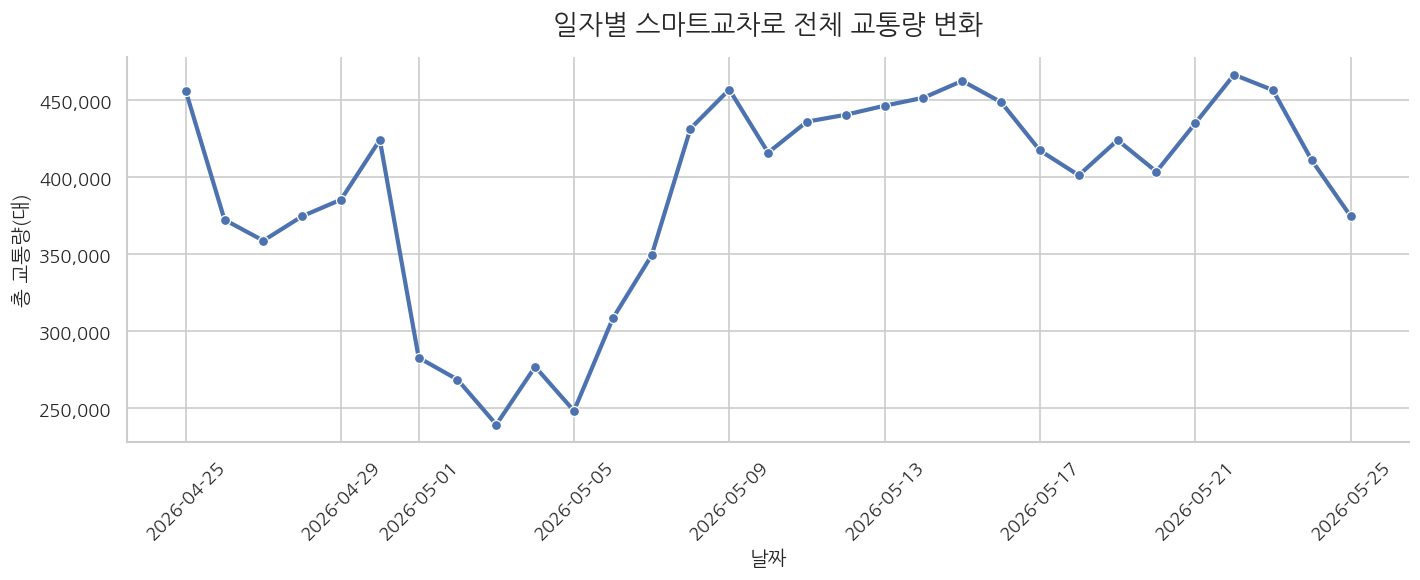

,날짜,총교통량
0,2026-04-25,456375
1,2026-04-26,372492
2,2026-04-27,358917
3,2026-04-28,374786
4,2026-04-29,385581
5,2026-04-30,424372
6,2026-05-01,282932
7,2026-05-02,268699
8,2026-05-03,239449
9,2026-05-04,277040


In [4]:
# ============================================================
# 3. 일자별 전체 교통량 변화
# ============================================================

daily_total = (
    analysis_df.groupby("DATE", as_index=False)["DAILY_TOTAL"]
    .sum()
    .sort_values("DATE")
)

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=daily_total, x="DATE", y="DAILY_TOTAL", marker="o", linewidth=2.5)
ax.yaxis.set_major_formatter(comma)
plt.title("일자별 스마트교차로 전체 교통량 변화", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("날짜")
plt.ylabel("총 교통량(대)")
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

display(daily_total.rename(columns={"DATE": "날짜", "DAILY_TOTAL": "총교통량"}))

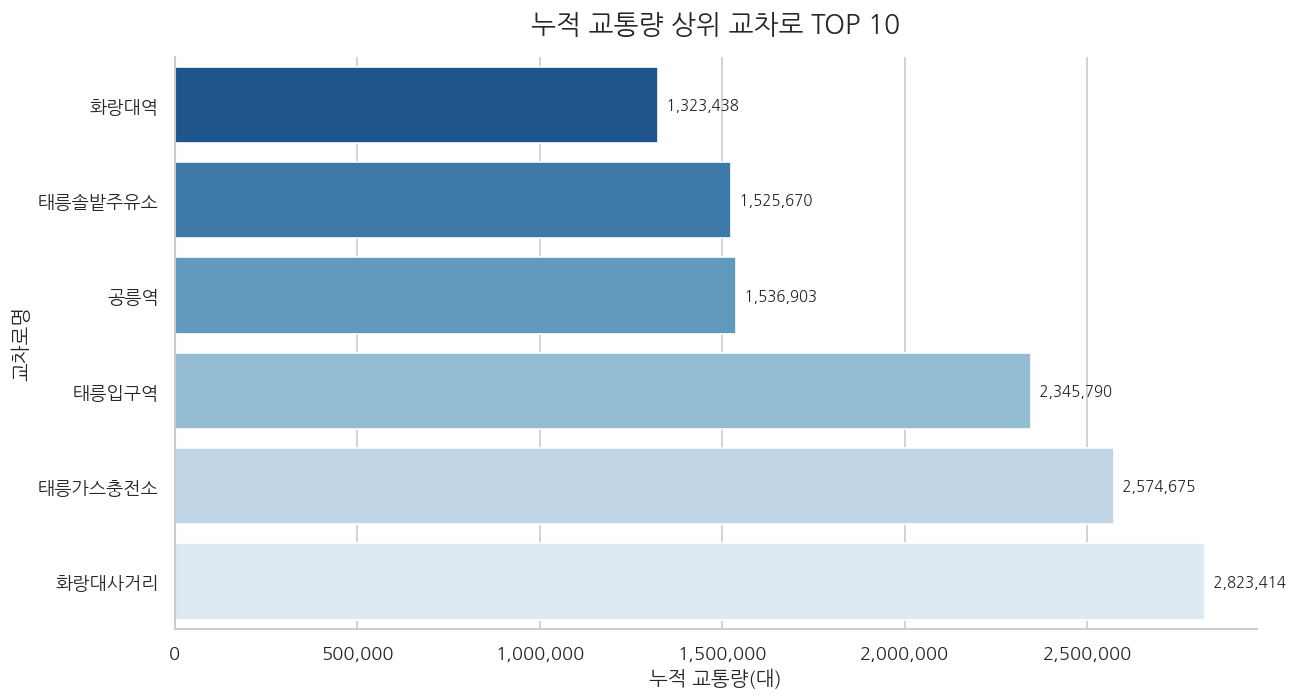

,교차로명,누적교통량
4,화랑대사거리,2823414
1,태릉가스충전소,2574675
3,태릉입구역,2345790
0,공릉역,1536903
2,태릉솔밭주유소,1525670
5,화랑대역,1323438


In [5]:
# ============================================================
# 4. 교통량 상위 교차로 TOP 10
# ============================================================

intersection_total = (
    analysis_df.groupby("CROSS_NM", as_index=False)["DAILY_TOTAL"]
    .sum()
    .sort_values("DAILY_TOTAL", ascending=False)
)

top10 = intersection_total.head(10).sort_values("DAILY_TOTAL")

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=top10, x="DAILY_TOTAL", y="CROSS_NM", hue="CROSS_NM",
                 palette="Blues_r", legend=False)
ax.xaxis.set_major_formatter(comma)
plt.title("누적 교통량 상위 교차로 TOP 10", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("누적 교통량(대)")
plt.ylabel("교차로명")

for idx, value in enumerate(top10["DAILY_TOTAL"]):
    plt.text(value, idx, f"  {value:,.0f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

display(intersection_total.head(10).rename(columns={"CROSS_NM": "교차로명", "DAILY_TOTAL": "누적교통량"}))

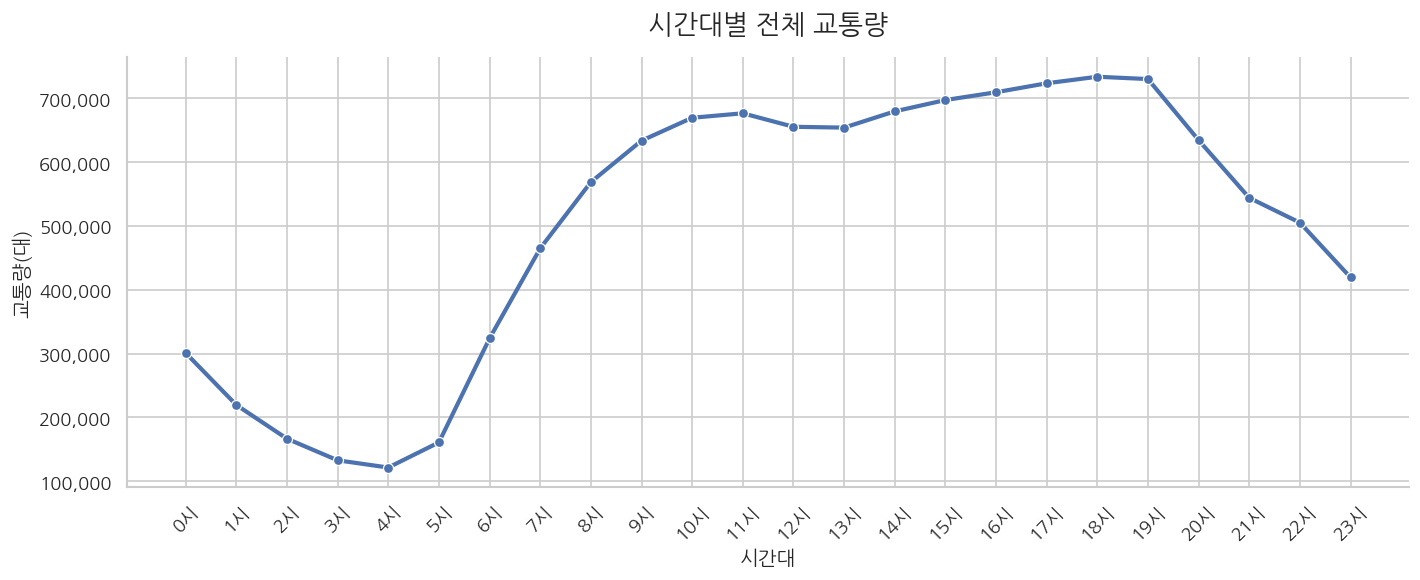

교통량이 가장 높은 시간대: 18시 (734,087대)


In [6]:
# ============================================================
# 5. 시간대별 전체 교통량
# ============================================================

hourly_total = analysis_df[hour_cols].sum()
hourly_total.index = range(24)
hourly_total = hourly_total.reset_index()
hourly_total.columns = ["시간", "교통량"]

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=hourly_total, x="시간", y="교통량", marker="o", linewidth=2.5)
ax.yaxis.set_major_formatter(comma)
plt.xticks(range(24), [f"{h}시" for h in range(24)], rotation=45)
plt.title("시간대별 전체 교통량", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("시간대")
plt.ylabel("교통량(대)")
sns.despine()
plt.tight_layout()
plt.show()

peak_hour = int(hourly_total.loc[hourly_total["교통량"].idxmax(), "시간"])
peak_volume = hourly_total["교통량"].max()
print(f"교통량이 가장 높은 시간대: {peak_hour}시 ({peak_volume:,.0f}대)")

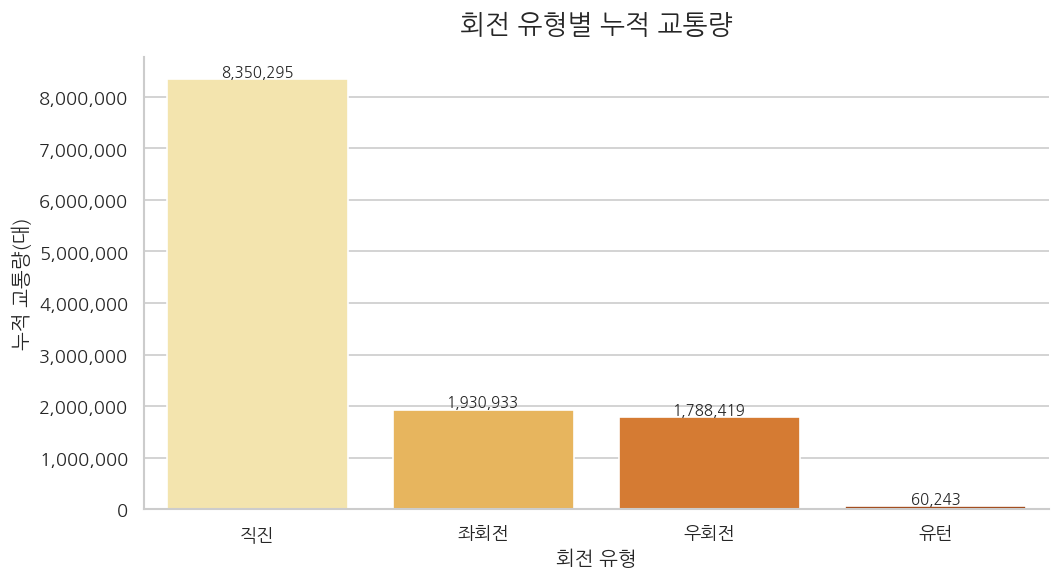

,회전유형,누적교통량
3,직진,8350295
2,좌회전,1930933
0,우회전,1788419
1,유턴,60243


In [7]:
# ============================================================
# 6. 회전 유형별 교통량 비교
# ============================================================

turn_total = (
    analysis_df.groupby("TURN_TYPE_NM", as_index=False)["DAILY_TOTAL"]
    .sum()
    .sort_values("DAILY_TOTAL", ascending=False)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=turn_total, x="TURN_TYPE_NM", y="DAILY_TOTAL",
                 hue="TURN_TYPE_NM", palette="YlOrBr", legend=False)
ax.yaxis.set_major_formatter(comma)
plt.title("회전 유형별 누적 교통량", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("회전 유형")
plt.ylabel("누적 교통량(대)")

for i, value in enumerate(turn_total["DAILY_TOTAL"]):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

display(turn_total.rename(columns={"TURN_TYPE_NM": "회전유형", "DAILY_TOTAL": "누적교통량"}))

In [8]:
# ============================================================
# 7. 분석 결과 자동 요약
# ============================================================

top_cross = intersection_total.iloc[0]
top_date = daily_total.loc[daily_total["DAILY_TOTAL"].idxmax()]
top_turn = turn_total.iloc[0]

print("=" * 65)
print("스마트교차로 일일 교통량 분석 결과 요약")
print("=" * 65)
print(f"분석 기간: {analysis_df['DATE'].min().date()} ~ {analysis_df['DATE'].max().date()}")
print(f"분석 교차로 수: {analysis_df['CROSS_NM'].nunique()}개")
print(f"전체 누적 교통량: {analysis_df['DAILY_TOTAL'].sum():,.0f}대")
print(f"누적 교통량이 가장 높은 교차로: {top_cross['CROSS_NM']} ({top_cross['DAILY_TOTAL']:,.0f}대)")
print(f"전체 교통량이 가장 높은 날짜: {top_date['DATE'].date()} ({top_date['DAILY_TOTAL']:,.0f}대)")
print(f"전체 교통량이 가장 높은 시간대: {peak_hour}시 ({peak_volume:,.0f}대)")
print(f"교통량이 가장 많은 회전 유형: {top_turn['TURN_TYPE_NM']} ({top_turn['DAILY_TOTAL']:,.0f}대)")
print("=" * 65)

스마트교차로 일일 교통량 분석 결과 요약
분석 기간: 2026-04-25 ~ 2026-05-25
분석 교차로 수: 6개
전체 누적 교통량: 12,129,890대
누적 교통량이 가장 높은 교차로: 화랑대사거리 (2,823,414대)
전체 교통량이 가장 높은 날짜: 2026-05-22 (466,720대)
전체 교통량이 가장 높은 시간대: 18시 (734,087대)
교통량이 가장 많은 회전 유형: 직진 (8,350,295대)


---

# 지도 시각화 추가

아래 셀부터는 `서울시 노드 정보.csv`를 불러와 교통량 파일의 `CROSS_NM`과 위치 파일의 `노드명`을 연결합니다.

- 좌표가 연결된 교차로는 지도 위에 원으로 표시됩니다.
- 원이 클수록 누적 교통량이 많습니다.
- 연결되지 않은 교차로는 별도 CSV 파일로 저장하여 확인할 수 있습니다.

In [9]:
# ============================================================
# 8. 지도용 서울시 노드 정보 CSV 업로드 및 불러오기
# ============================================================

import folium
from google.colab import files

print("서울시 노드 정보.csv 파일을 선택하세요.")
node_uploaded = files.upload()

node_csv_files = [name for name in node_uploaded.keys() if name.lower().endswith(".csv")]
if not node_csv_files:
    raise ValueError("CSV 파일을 선택하지 않았습니다. 서울시 노드 정보.csv를 업로드하세요.")

node_file_path = node_csv_files[0]
node_df = None

for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
    try:
        node_df = pd.read_csv(node_file_path, encoding=enc)
        print(f"노드 정보 CSV 불러오기 완료: {node_file_path} / 인코딩: {enc}")
        break
    except UnicodeDecodeError:
        continue

if node_df is None:
    raise ValueError("노드 정보 CSV의 인코딩을 확인할 수 없습니다.")

required_node_cols = ["노드명", "X좌표", "Y좌표"]
missing_node_cols = [col for col in required_node_cols if col not in node_df.columns]

if missing_node_cols:
    raise ValueError(
        f"서울시 노드 정보 CSV에 필요한 컬럼이 없습니다: {missing_node_cols}\n"
        f"현재 컬럼: {node_df.columns.tolist()}"
    )

print("노드 정보 데이터 크기:", node_df.shape)
print("노드 정보 컬럼:", node_df.columns.tolist())
display(node_df.head())

서울시 노드 정보.csv 파일을 선택하세요.


Saving 서울시 노드 정보.csv to 서울시 노드 정보.csv
노드 정보 CSV 불러오기 완료: 서울시 노드 정보.csv / 인코딩: utf-8-sig
노드 정보 데이터 크기: (10177, 10)
노드 정보 컬럼: ['노드ID', '노드명', '노드유형코드', '노드유형명', '회전제한유무', '회전제한유무명', 'X좌표', 'Y좌표', 'TM_X좌표', 'TM_Y좌표']


,노드ID,노드명,노드유형코드,노드유형명,회전제한유무,회전제한유무명,X좌표,Y좌표,TM_X좌표,TM_Y좌표
0,1000001300,신설동역,101,도로교차점,1,유,127.023227,37.575581,202051.824057,452892.926984
1,1000001400,홍지문터널북측,104,도로시설물,0,무,126.972004,37.605901,197527.925278,456258.244559
2,1000001600,청계3가,101,도로교차점,1,유,126.992352,37.568518,199324.342020,452108.771316
3,1000002000,청계광장,101,도로교차점,0,무,126.977106,37.569031,197977.458986,452165.982278
4,1000002500,종로구청,101,도로교차점,0,무,126.979242,37.572469,198166.251907,452547.532554


In [10]:
# ============================================================
# 9. 교통량 데이터와 좌표 데이터 연결
# ============================================================

# 교차로명 정리 함수: 띄어쓰기 차이로 인한 결합 실패를 줄임
def clean_name(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
    )

# 교차로별 누적 교통량 계산
traffic_by_cross = (
    analysis_df.groupby("CROSS_NM", as_index=False)["DAILY_TOTAL"]
    .sum()
    .rename(columns={"CROSS_NM": "교차로명", "DAILY_TOTAL": "총교통량"})
)

traffic_by_cross["연결키"] = clean_name(traffic_by_cross["교차로명"])

# 위치 데이터 정리
node_map = node_df[["노드명", "X좌표", "Y좌표"]].copy()
node_map["연결키"] = clean_name(node_map["노드명"])
node_map["X좌표"] = pd.to_numeric(node_map["X좌표"], errors="coerce")
node_map["Y좌표"] = pd.to_numeric(node_map["Y좌표"], errors="coerce")
node_map = node_map.dropna(subset=["X좌표", "Y좌표"])

# 서울 경위도 범위를 벗어난 행 제거
node_map = node_map[
    node_map["X좌표"].between(126.70, 127.30) &
    node_map["Y좌표"].between(37.40, 37.75)
].copy()

# 동일 이름의 위치가 여러 개면 평균 좌표를 사용
duplicate_count = int(node_map.duplicated("연결키", keep=False).sum())
if duplicate_count > 0:
    print(f"중복된 노드명 좌표 행 수: {duplicate_count}행 — 평균 좌표로 통합합니다.")

node_one_point = (
    node_map.groupby("연결키", as_index=False)
    .agg(
        노드명=("노드명", "first"),
        X좌표=("X좌표", "mean"),
        Y좌표=("Y좌표", "mean")
    )
)

# 교통량과 위치 연결
map_df = pd.merge(
    traffic_by_cross,
    node_one_point,
    on="연결키",
    how="left"
)

mapped_df = map_df.dropna(subset=["X좌표", "Y좌표"]).copy()
unmapped_df = map_df[map_df["X좌표"].isna()].copy()

total_cross = len(map_df)
mapped_cross = len(mapped_df)
match_rate = mapped_cross / total_cross * 100 if total_cross else 0

print("=" * 62)
print("교통량 데이터와 서울시 노드 좌표 연결 결과")
print("=" * 62)
print(f"전체 교통량 교차로 수: {total_cross:,}개")
print(f"지도 표시 가능한 교차로 수: {mapped_cross:,}개")
print(f"위치가 연결되지 않은 교차로 수: {len(unmapped_df):,}개")
print(f"교차로 연결률: {match_rate:.1f}%")
print("=" * 62)

if mapped_df.empty:
    raise ValueError(
        "교통량의 CROSS_NM과 노드 정보의 노드명이 연결되지 않습니다. "
        "두 파일의 교차로명 표기 방식을 확인하세요."
    )

print("\n지도 표시 데이터 예시:")
display(mapped_df[["교차로명", "총교통량", "X좌표", "Y좌표"]].head())

if len(unmapped_df) > 0:
    print("\n좌표가 연결되지 않은 교차로 예시:")
    display(unmapped_df[["교차로명", "총교통량"]].head(15))

중복된 노드명 좌표 행 수: 1944행 — 평균 좌표로 통합합니다.
교통량 데이터와 서울시 노드 좌표 연결 결과
전체 교통량 교차로 수: 6개
지도 표시 가능한 교차로 수: 4개
위치가 연결되지 않은 교차로 수: 2개
교차로 연결률: 66.7%

지도 표시 데이터 예시:


,교차로명,총교통량,X좌표,Y좌표
0,공릉역,1536903,127.073005,37.625619
3,태릉입구역,2345790,127.075674,37.617674
4,화랑대사거리,2823414,127.087226,37.621588
5,화랑대역,1323438,127.088399,37.622611



좌표가 연결되지 않은 교차로 예시:


,교차로명,총교통량
1,태릉가스충전소,2574675
2,태릉솔밭주유소,1525670


In [11]:
# ============================================================
# 10. 교차로별 누적 교통량 Folium 점 지도 생성
# ============================================================

# 지도 중심: 좌표가 연결된 교차로의 평균 위치
map_center = [mapped_df["Y좌표"].mean(), mapped_df["X좌표"].mean()]

traffic_map = folium.Map(
    location=map_center,
    zoom_start=11,
    tiles="CartoDB positron",
    control_scale=True
)

max_traffic = mapped_df["총교통량"].max()

# 교통량이 적은 점을 먼저 그려 큰 원이 위에 보이도록 처리
for _, row in mapped_df.sort_values("총교통량").iterrows():
    ratio = row["총교통량"] / max_traffic if max_traffic > 0 else 0
    radius = 4 + np.sqrt(ratio) * 20

    popup_html = f'''
    <div style="font-family: sans-serif; width: 210px;">
        <b>{row["교차로명"]}</b><br>
        누적 교통량: {row["총교통량"]:,.0f}대<br>
        경도: {row["X좌표"]:.6f}<br>
        위도: {row["Y좌표"]:.6f}
    </div>
    '''

    folium.CircleMarker(
        location=[row["Y좌표"], row["X좌표"]],
        radius=radius,
        tooltip=f'{row["교차로명"]}: {row["총교통량"]:,.0f}대',
        popup=folium.Popup(popup_html, max_width=260),
        color="#9E2A2B",
        fill=True,
        fill_color="#E63946",
        fill_opacity=0.60,
        weight=1
    ).add_to(traffic_map)

# 상위 10개 교차로 이름 라벨 표시
top_map_points = mapped_df.nlargest(10, "총교통량")
for _, row in top_map_points.iterrows():
    folium.Marker(
        location=[row["Y좌표"], row["X좌표"]],
        tooltip=f'TOP 10 - {row["교차로명"]}',
        icon=folium.DivIcon(
            html=f'''
            <div style="
                font-size: 10px;
                font-weight: bold;
                color: #7F0000;
                white-space: nowrap;
                background: rgba(255,255,255,0.8);
                padding: 2px 4px;
                border-radius: 3px;">
                {row["교차로명"]}
            </div>
            '''
        )
    ).add_to(traffic_map)

title_html = '''
<div style="
    position: fixed;
    top: 10px;
    left: 50px;
    z-index: 9999;
    background-color: white;
    padding: 10px 14px;
    border: 1px solid #cccccc;
    border-radius: 7px;
    box-shadow: 0 1px 4px rgba(0,0,0,0.2);
    font-size: 15px;
    font-weight: bold;">
    스마트교차로 누적 교통량 분포 지도<br>
    <span style="font-size: 11px; font-weight: normal;">
    원이 클수록 누적 교통량이 많음
    </span>
</div>
'''
traffic_map.get_root().html.add_child(folium.Element(title_html))

display(traffic_map)

In [12]:
# ============================================================
# 11. 지도 HTML 및 연결 결과 CSV 저장·다운로드
# ============================================================

map_output_file = "스마트교차로_누적교통량_점지도.html"
mapped_output_file = "지도표시_가능_교차로.csv"
unmapped_output_file = "지도위치_미연결_교차로.csv"

traffic_map.save(map_output_file)

mapped_df[["교차로명", "총교통량", "X좌표", "Y좌표"]].to_csv(
    mapped_output_file, index=False, encoding="utf-8-sig"
)

unmapped_df[["교차로명", "총교통량"]].to_csv(
    unmapped_output_file, index=False, encoding="utf-8-sig"
)

print("저장 완료:")
print(f"- 지도 파일: {map_output_file}")
print(f"- 지도 표시 가능 교차로: {mapped_output_file}")
print(f"- 위치 미연결 교차로: {unmapped_output_file}")

print("\n지도를 먼저 다운로드합니다.")
files.download(map_output_file)

# 아래 두 파일도 필요하면 주석(#)을 삭제하고 각각 실행하세요.
# files.download(mapped_output_file)
# files.download(unmapped_output_file)

저장 완료:
- 지도 파일: 스마트교차로_누적교통량_점지도.html
- 지도 표시 가능 교차로: 지도표시_가능_교차로.csv
- 위치 미연결 교차로: 지도위치_미연결_교차로.csv

지도를 먼저 다운로드합니다.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 결과 해석 작성 예시

교차로별 교통량 데이터와 서울시 노드 좌표 데이터를 결합하여 지도 시각화를 수행하였다. 지도에서 원의 크기는 각 교차로의 누적 교통량을 의미하며, 큰 원이 표시된 지역일수록 분석 기간 동안 차량 통행이 집중된 지점이다. 기존의 막대그래프는 교통량 순위를 비교하는 데 유용하고, 점 지도는 교통량이 집중되는 공간적 위치를 파악하는 데 유용하다.

### 주의사항
이 지도는 `CROSS_NM`과 `노드명`이 일치하는 교차로만 표시합니다. 실행 시 출력되는 **교차로 연결률**이 낮다면, 연결되지 않은 교차로명 CSV를 확인하여 이름 표기를 보정해야 합니다.